In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
AUC_DIR = "/home/users/mendrika/NCAST/Output/evaluation/ncast/auc"
FSS_DIR = "/home/users/mendrika/NCAST/Output/evaluation/ncast/fss"

MODELS = [
    "base",
    "noattention",
    "notimefeat",
    "t0",
    "t0_tminus1h",
    "t0_tminus1h_tminus2h",
]

MODEL_LABELS = {
    "base": "NCAST",
    "noattention": "No self-attention",
    "notimefeat": "No temporal features",
    "t0": r"$t_0$",
    "t0_tminus1h": r"$t_0,\ t_{-1}$",
    "t0_tminus1h_tminus2h": r"$t_0,\ t_{-1},\ t_{-2}$",
}


COLOURS = {
    "NCAST": "#1f77b4",
    "No self-attention": "#ff7f0e",
    "No temporal features": "#2ca02c",
    r"$t_0$": "#7f7f7f",
    r"$t_0,\ t_{-1}$": "#7f7f7f",
    r"$t_0,\ t_{-1},\ t_{-2}$": "#7f7f7f",
}

LEAD_TIMES = ["1", "3", "6"]

In [38]:
def load_auc_results():
    rows = []

    for model_name in MODELS:
        for lead_time in LEAD_TIMES:
            auc_model_path = os.path.join(
                AUC_DIR,
                model_name,
                f"auc_model_t{lead_time}.npy"
            )

            if not os.path.exists(auc_model_path):
                print(f"Missing: {auc_model_path}")
                continue

            rows.append({
                "model_name": model_name,
                "model_label": MODEL_LABELS[model_name],
                "lead_time": int(lead_time),
                "auc_model": float(np.load(auc_model_path)),
            })

    return pd.DataFrame(rows)

def load_fss_results():
    rows = []

    for model_name in MODELS:
        for lead_time in LEAD_TIMES:
            csv_path = os.path.join(
                FSS_DIR,
                model_name,
                f"fss_all_scenes_t{lead_time}.csv",
            )

            if not os.path.exists(csv_path):
                print(f"Missing: {csv_path}")
                continue

            df = pd.read_csv(csv_path)
            df["model_name"] = model_name
            df["model_label"] = MODEL_LABELS[model_name]
            df["lead_time"] = int(lead_time)
            rows.append(df)

    return pd.concat(rows, ignore_index=True)

auc_df = load_auc_results()
fss_df = load_fss_results()

window_px = 49
scale_km = window_px * 3

fss_plot = fss_df[
    (fss_df["window_px"] == window_px) &
    (fss_df["case_type"] == "all_scenes")
].copy()

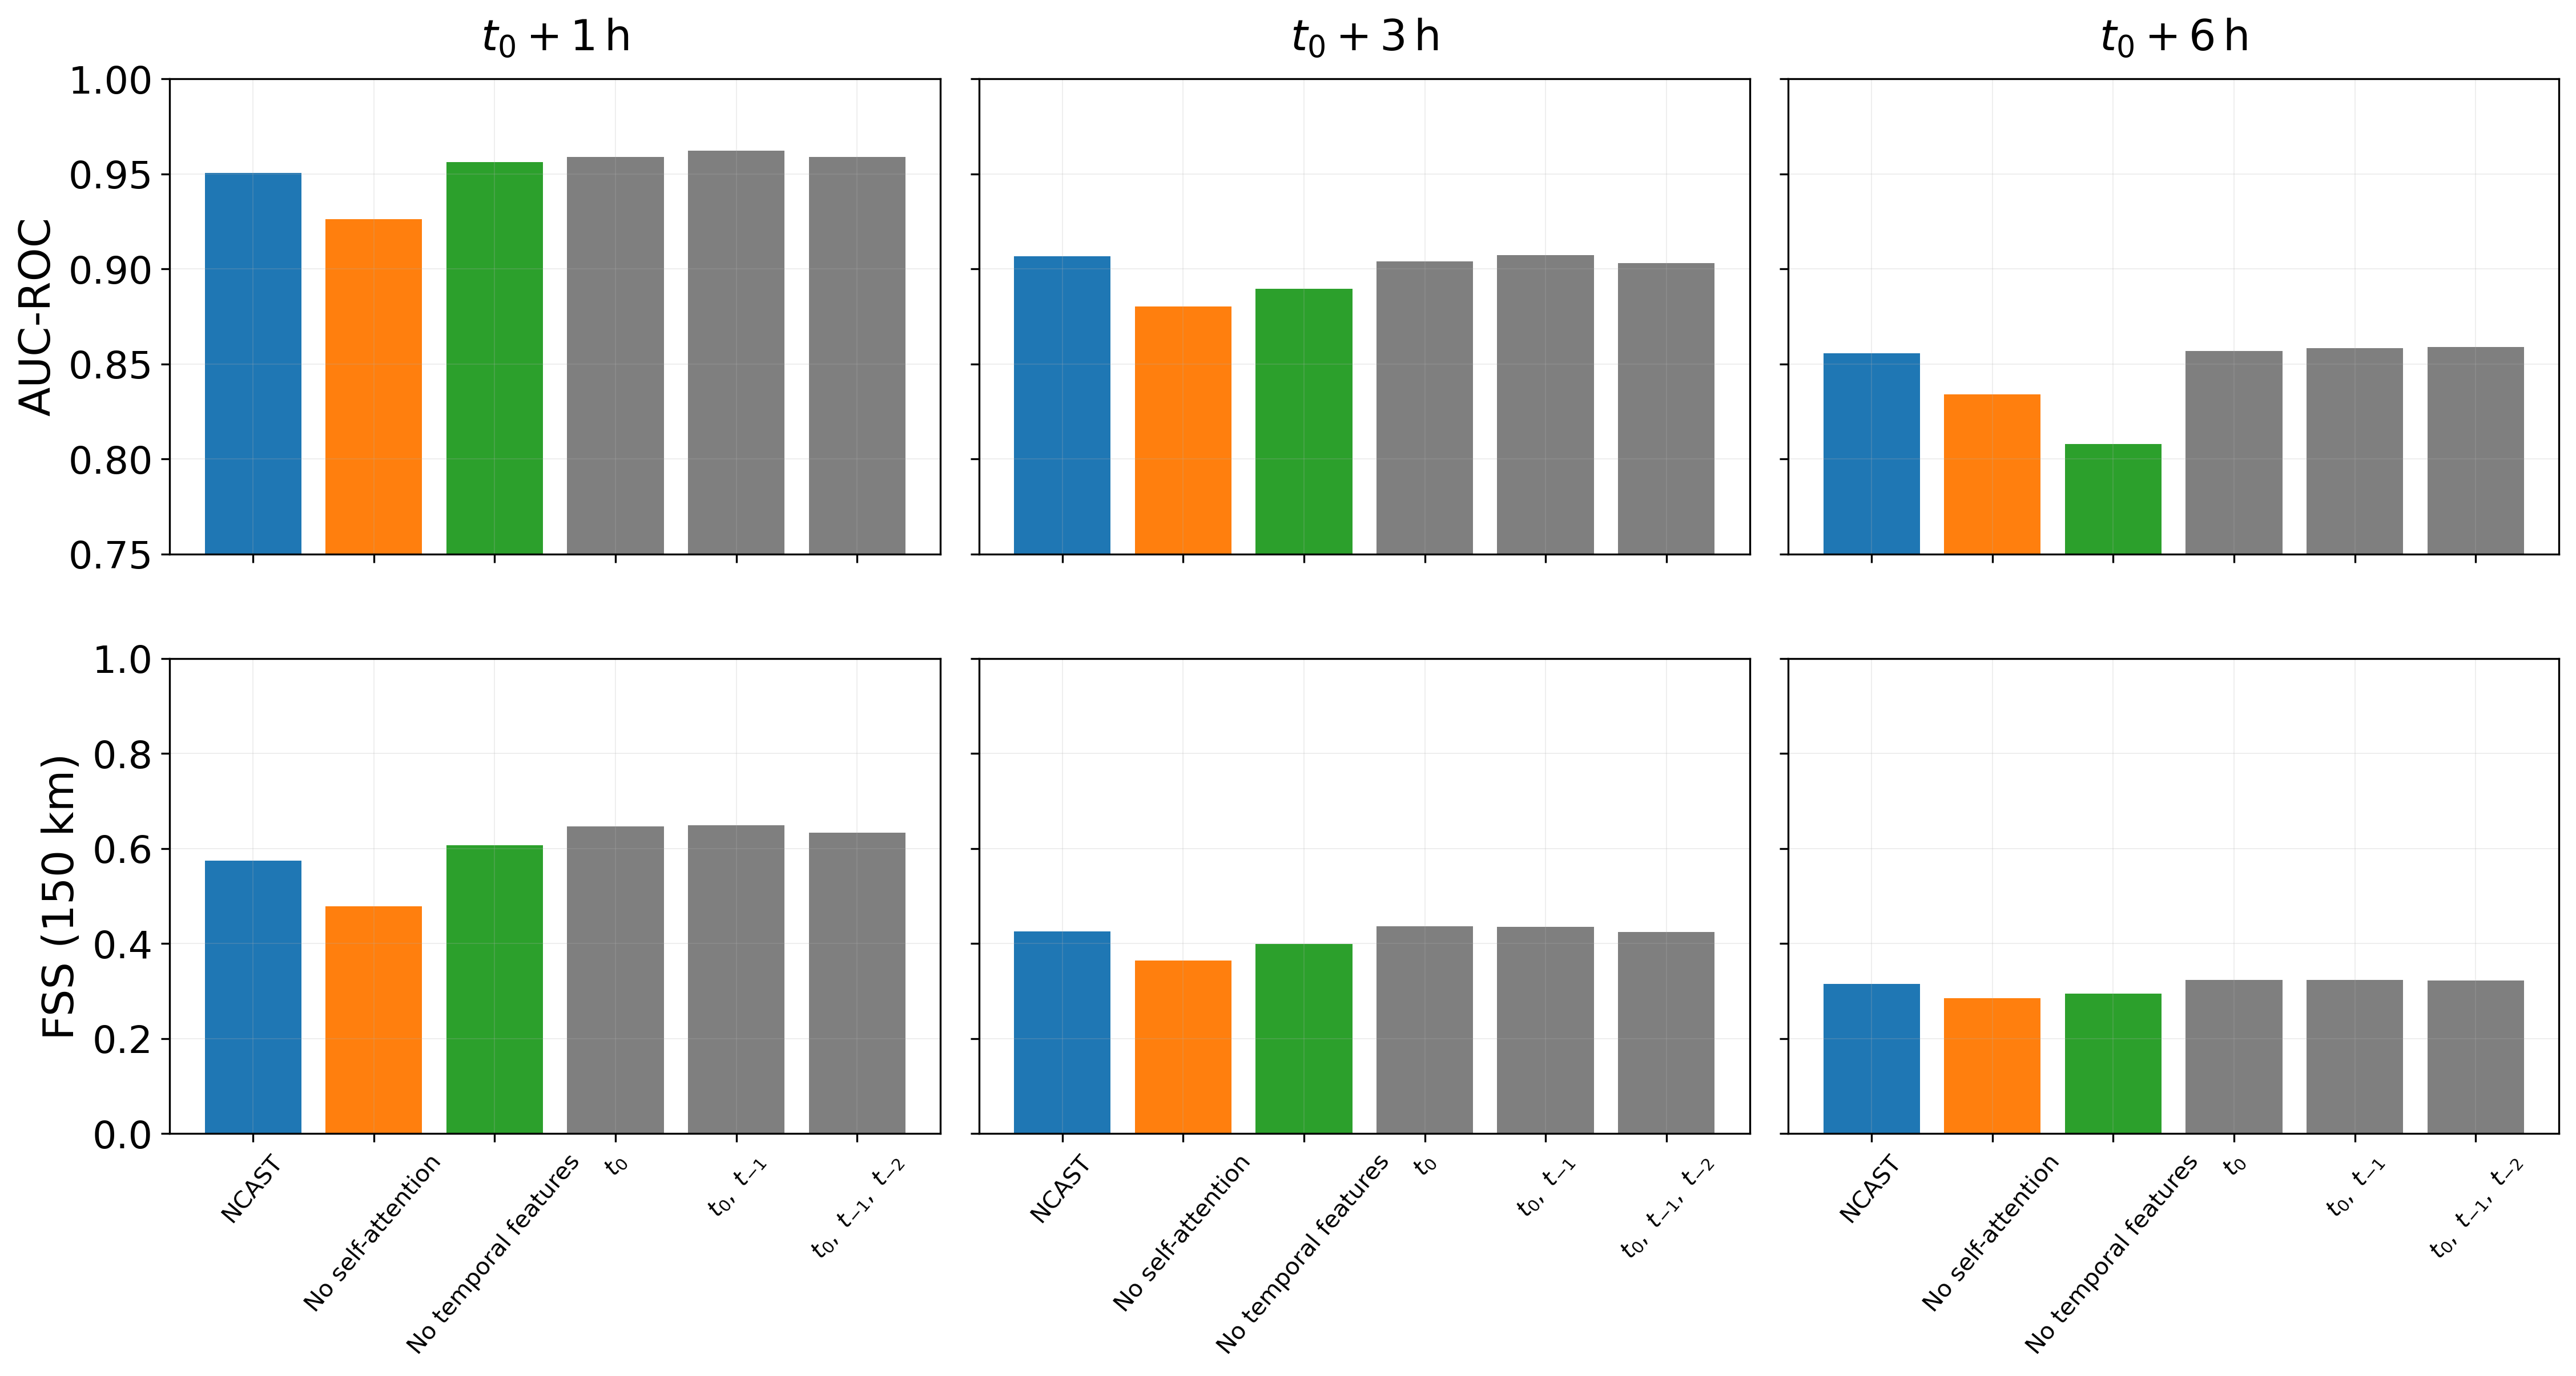

In [40]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 8),
    dpi=300,
)

plt.subplots_adjust(
    wspace=0.05,
    hspace=0.22
)

for col, lead_time in enumerate([1, 3, 6]):

    auc_subset = auc_df[
        auc_df["lead_time"] == lead_time
    ]

    ax = axes[0, col]

    ax.bar(
        auc_subset["model_label"],
        auc_subset["auc_model"],
        color=[COLOURS[label] for label in auc_subset["model_label"]]
    )

    ax.set_ylim(0.75, 1.0)

    ax.set_title(
        rf"$t_0 + {lead_time}\,\mathrm{{h}}$",
        fontsize=18,
        pad=12
    )

    ax.tick_params(axis="x", labelbottom=False)
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(True, linewidth=0.1)

    if col == 0:
        ax.set_ylabel("AUC-ROC", fontsize=18)
    else:
        ax.tick_params(axis="y", labelleft=False)        

    fss_subset = fss_plot[
        fss_plot["lead_time"] == lead_time
    ]

    ax = axes[1, col]

    ax.bar(
        fss_subset["model_label"],
        fss_subset["smooth_model"],
        color=[COLOURS[label] for label in fss_subset["model_label"]]
    )

    ax.set_ylim(0.0, 1.0)

    ax.tick_params(axis="x", rotation=50, labelsize=10)
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(True, linewidth=0.1)

    if col == 0:
        ax.set_ylabel(f"FSS (150 km)", fontsize=18)
    else:
        ax.tick_params(axis="y", labelleft=False)

plt.show()